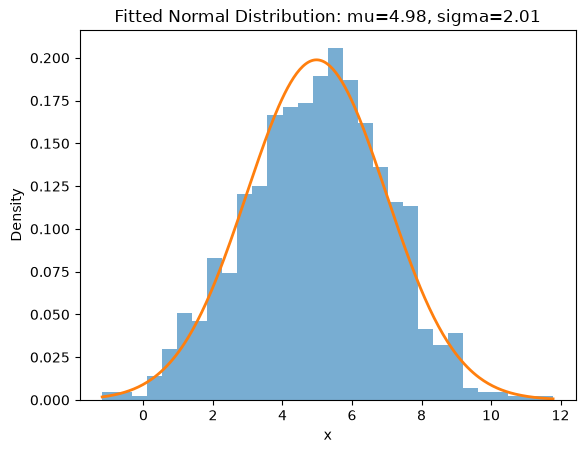

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
data = np.random.normal(loc=5,scale=2,size=1000)
mu = np.mean(data)
sigma = np.std(data)
x = np.linspace(data.min(),data.max(),300)
y = norm.pdf(x,mu,sigma)
plt.hist(data,bins=30,density=True,alpha=0.6)
plt.plot(x,y,linewidth=2)
plt.title(f"Fitted Normal Distribution: mu={mu:.2f}, sigma={sigma:.2f}")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()


In [6]:
import numpy as np
x = np.random.randn(32,28,28)
x_flat = x.reshape(x.shape[0],-1)
print(x_flat.shape)

(32, 784)


In [7]:
import numpy as np
import torch
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score

# 1. 加载并展平 MNIST 数据
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 转为 numpy 方便矩阵运算
X_train = train_dataset.data.numpy().reshape(-1, 784).astype(np.float64) / 255.0
y_train = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy().reshape(-1, 784).astype(np.float64) / 255.0
y_test = test_dataset.targets.numpy()

# 2. 拟合模型：计算每个类别的 mu 和 对角 sigma^2
mus = []
log_vars = [] # 存储方差的对数，防止下溢
priors = []   # 先验概率 P(Y=k)

epsilon = 1e-6 # 平滑项，防止方差为0导致 log(0)

for k in range(10):
    X_k = X_train[y_train == k]
    N_k = X_k.shape[0]
    
    # 计算均值 (784维)
    mu_k = np.mean(X_k, axis=0)
    mus.append(mu_k)
    
    # 计算方差 (784维)，加上 epsilon 防止0方差
    var_k = np.var(X_k, axis=0) + epsilon
    # 【核心技巧】：存储 log(var)，为后续计算对数概率做准备
    log_vars.append(np.log(var_k)) 
    
    # 计算先验概率
    priors.append(N_k / X_train.shape[0])

mus = np.array(mus)           # Shape: (10, 784)
log_vars = np.array(log_vars) # Shape: (10, 784)
priors = np.log(np.array(priors)) # 取对数

# 3. 预测函数：使用对数概率 (Log-Likelihood) 避免下溢
def predict(X):
    # X shape: (Batch, 784)
    log_probs = np.zeros((X.shape[0], 10))
    
    for k in range(10):
        mu_k = mus[k]
        log_var_k = log_vars[k]
        
        # 对角协方差的高斯对数概率密度公式展开：
        # log P(x|k) = -0.5 * [ d*log(2pi) + sum(log_var) + sum((x-mu)^2 / var) ]
        d = 784
        term1 = d * np.log(2 * np.pi)
        term2 = np.sum(log_var_k)
        # 利用广播机制计算整个 Batch 的平方差
        term3 = np.sum(((X - mu_k)**2) / np.exp(log_var_k), axis=1) 
        
        log_p_x_given_k = -0.5 * (term1 + term2 + term3)
        
        # 加上先验概率的对数: log P(x, k) = log P(x|k) + log P(k)
        log_probs[:, k] = log_p_x_given_k + priors[k]
        
    # 返回概率最大的类别
    return np.argmax(log_probs, axis=1)

# 4. 评估
y_pred = predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"对角高斯模型 (Naive Bayes) 测试集准确率: {acc * 100:.2f}%")

ModuleNotFoundError: No module named 'torch'